# Parameter sweep

An emulator evaluates a planet in milliseconds, so a scan over parameter space that would take thousands of GCM runs takes seconds. We sweep instellation (`F_star`) against CO2 and map the global-mean surface temperature.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from clero import Emulator
from clero.climate_analysis import global_mean, latitude_centers

## Build the grid

A 20 × 20 grid is 400 planets, passed as one batch in the column-dict form: every key holds a full-length sequence (mixing scalars and sequences raises an error), so the fixed parameters are broadcast with `np.full` and `GCM` is a list. All values lie inside the core domain.

In [2]:
emu = Emulator()

f_star = np.linspace(600.0, 1400.0, 20)
co2 = np.logspace(-4, -1, 20)
FF, CC = np.meshgrid(f_star, co2)            # both (20, 20): rows = CO2, cols = F_star
n = FF.size

base = dict(T_star=3000.0, radius=1.0, gravity=9.8, P_rot=10.0, P0=1.0, CH4=0.0)
batch = {key: np.full(n, value) for key, value in base.items()}
batch["F_star"] = FF.ravel()
batch["CO2"] = CC.ravel()
batch["GCM"] = ["um"] * n

pred = emu.predict(batch)
print("predicted", pred["surface_temperature"].shape[0], "planets")

predicted 400 planets


## Global-mean surface temperature

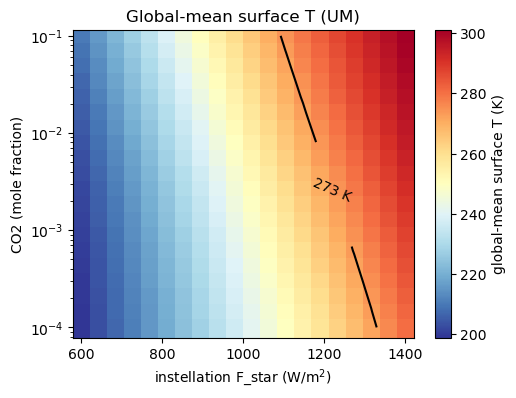

In [3]:
lat = latitude_centers(pred["surface_temperature"].shape[1])
gm = np.array([global_mean(s, lat) for s in pred["surface_temperature"]]).reshape(FF.shape)

fig, ax = plt.subplots(figsize=(5.5, 4))
pc = ax.pcolormesh(f_star, co2, gm, shading="auto", cmap="RdYlBu_r")
cs = ax.contour(f_star, co2, gm, levels=[273.15], colors="k")
ax.clabel(cs, fmt="%.0f K")
ax.set(xlabel="instellation F_star (W/m$^2$)", ylabel="CO2 (mole fraction)", yscale="log", title="Global-mean surface T (UM)")
fig.colorbar(pc, ax=ax, label="global-mean surface T (K)")
plt.show()

Both axes warm the planet, instellation directly and CO2 through its greenhouse effect; the 273 K contour marks the approximate freezing line.